#**HW 1 — Wine Classification**
##**1. Введение и постановка бизнес-задачи**

Целью проекта является разработка модели, позволяющей автоматически определять тип вина на основе его химических характеристик.

Такая модель может использоваться:

- для автоматизации контроля качества продукции,
- в системах рекомендаций,
- для классификации продукции на производстве.

Постановка ML-задачи

Задача формулируется как мультиклассовая классификация:

- класс 0 — один тип вина
- класс 1 — второй тип
- класс 2 — третий тип

##**2. Описание датасета**

Используется датасет:

Wine Dataset sklearn

Общая информация

Датасет содержит химический анализ вин, выращенных в одном регионе Италии, но относящихся к разным сортам.

Каждый объект описывает одно вино и включает набор численных признаков.

Основные характеристики
- Количество объектов: 178
- Количество признаков: 13
- Тип задачи: мультиклассовая классификация (3 класса)
- Пропуски: отсутствуют

Примеры признаков
- alcohol — содержание алкоголя
- malic_acid — яблочная кислота
- ash — зольность
- flavanoids — флавоноиды
- color_intensity — интенсивность цвета

Целевая переменная -
Тип вина (3 класса).

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.datasets import load_wine

##**3. Импорт библиотек и загрузка данных**

In [2]:
data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


##**4. Первичный анализ данных (EDA)**
Размер и структура

In [3]:
print("Размер датасета:", df.shape)

df.info()
df.describe()

Размер датасета: (178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


**Проверка пропусков**

In [4]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


**Вывод: пропущенные значения отсутствуют.**

**Проверка дубликатов**

In [5]:
df.duplicated().sum()

np.int64(0)

## **5. Анализ целевой переменной**

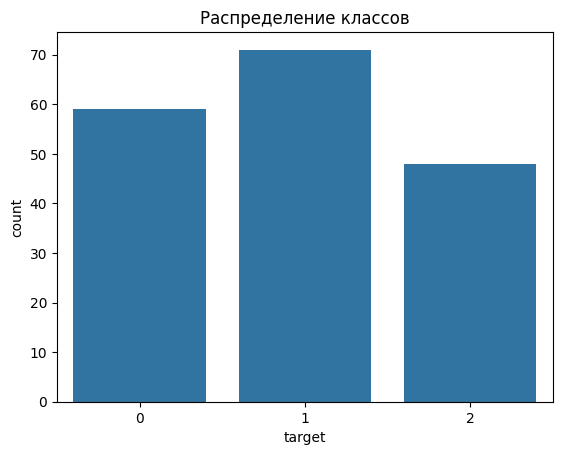

In [6]:
sns.countplot(data=df, x='target')
plt.title('Распределение классов')
plt.show()

**Вывод: классы распределены относительно равномерно, выраженного дисбаланса нет.**

##**6. Анализ признаков**
Распределения признаков

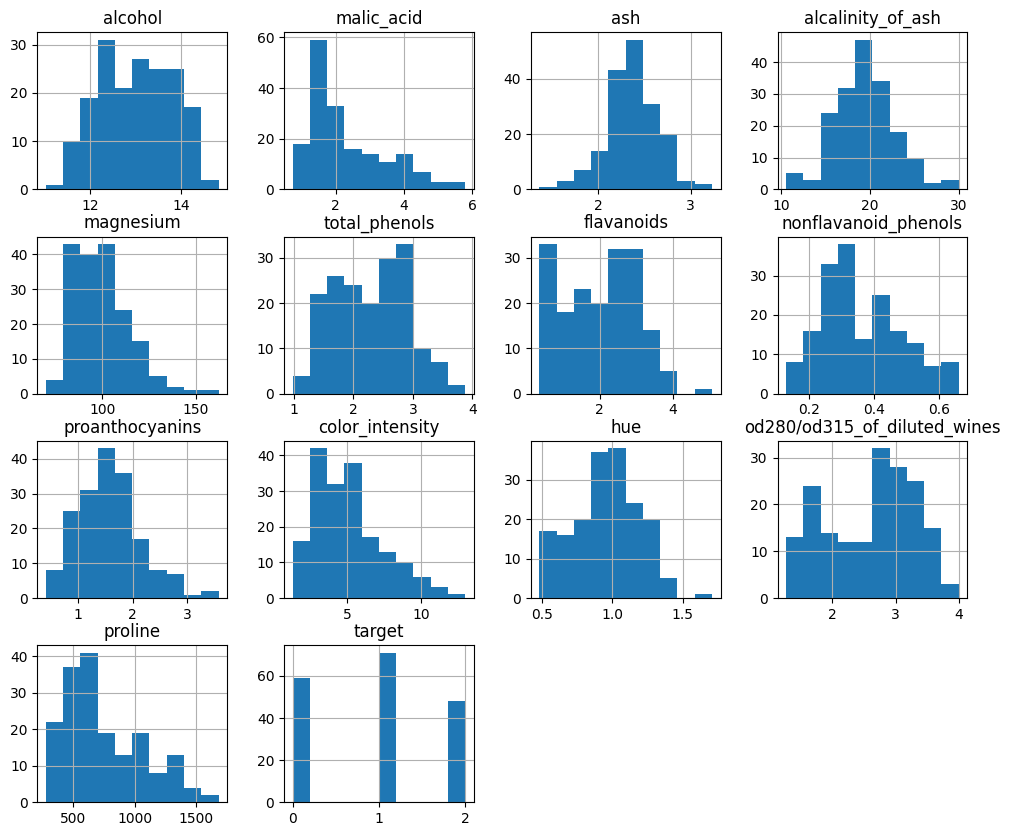

In [7]:
df.hist(figsize=(12,10))
plt.show()

**Вывод: признаки имеют различные масштабы и распределения, требуется нормализация.**

**Сравнение признаков по классам**

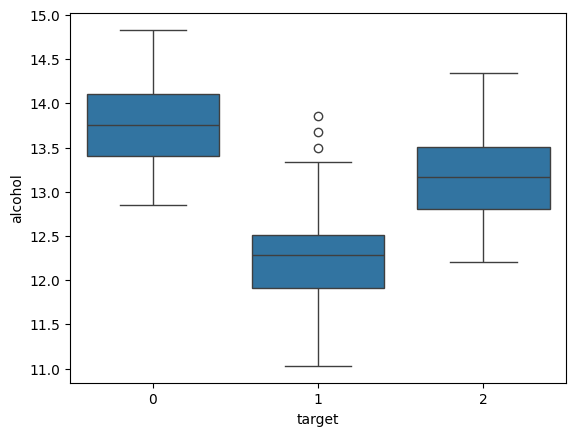

In [8]:
sns.boxplot(data=df, x='target', y='alcohol')
plt.show()

**Вывод: признак alcohol демонстрирует различия между классами и может быть информативным.**

**Корреляционный анализ**

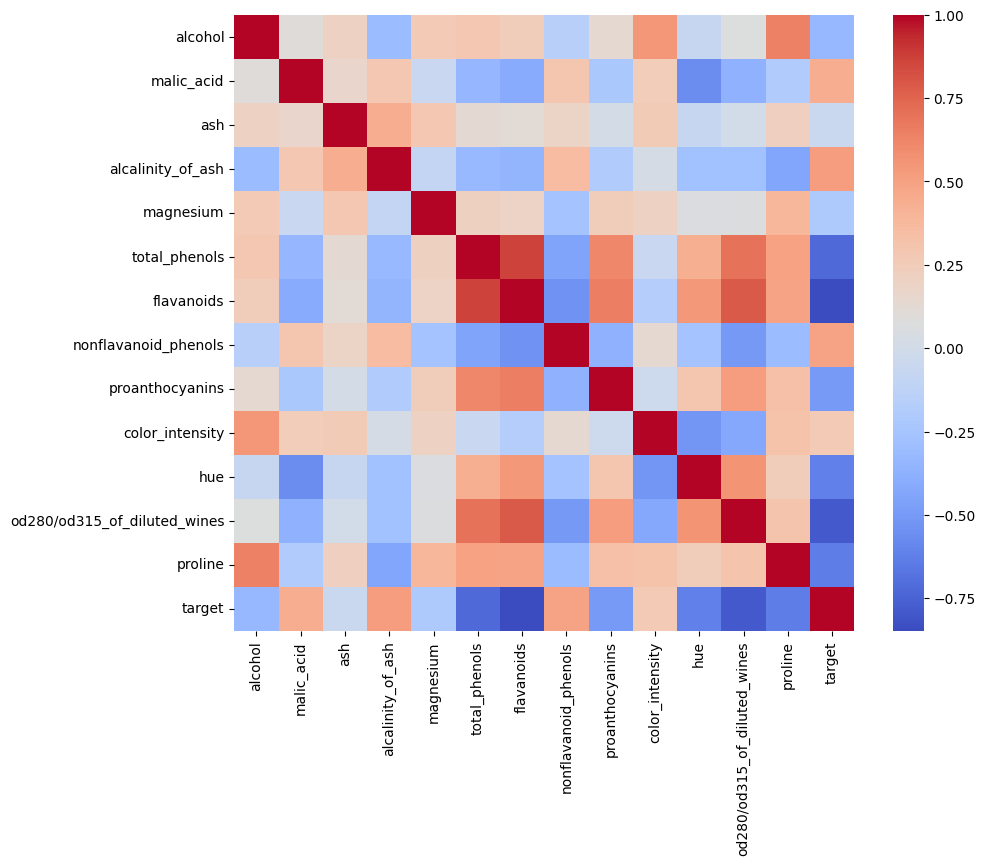

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

**Интерактивная визуализация**

In [10]:
fig = px.scatter(
    df,
    x='alcohol',
    y='color_intensity',
    color='target',
    title='Разделимость классов'
)
fig.show()

## **7. Подготовка данных**

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## **8. Обучение модели**

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## **9. Метрики и обоснование**

В качестве основной метрики выбрана accuracy, так как классы в датасете распределены достаточно равномерно. Дополнительно может использоваться macro-averaged F1-score для оценки качества по каждому классу.

## **10. Оценка качества**

In [13]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## **11. Интерпретация модели**

In [14]:
coeffs = pd.DataFrame({
    'feature': df.columns[:-1],
    'importance': model.coef_[0]
}).sort_values(by='importance', ascending=False)

coeffs.head(10)

,feature,importance
12,proline,1.037484
0,alcohol,0.744913
11,od280/od315_of_diluted_wines,0.650115
6,flavanoids,0.640936
2,ash,0.498562
5,total_phenols,0.212795
9,color_intensity,0.191483
8,proanthocyanins,0.184982
10,hue,0.174586
1,malic_acid,0.149939


## **12. Финальный вывод**

В рамках работы была решена задача классификации вин по их химическим характеристикам. Проведён разведочный анализ данных, который показал различия распределений признаков между классами и наличие корреляций. В качестве основной метрики использовалась accuracy. Построенная модель продемонстрировала хорошее качество и может быть применена для автоматизации задач контроля качества и категоризации продукции.